# Analytical Power Analysis

## Setup

In [ ]:

library(here)


here() starts at C:/Users/pablo/OneDrive/Github/cfa-power

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.

###############################################################################

This is semTools 0.5-8

All users of R (or SEM) are invited to submit functions or ideas for functions.

...


Attaching package: 'dplyr'

The following object is masked from 'package:MASS':

    select

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: SparseM

## Computing model degrees of freedom

The degrees of freedom are critical for the analytical approach because power is computed from the central and non-central χ² distributions, both parameterized by df.

In [ ]:

# Compute df directly with semPower (no data needed)
df_model <- semPower::semPower.getDf(analyzeModel)

cat("Model degrees of freedom (via semPower):", df_model, "\n")


Model degrees of freedom (via semPower): 249 

## A priori power analysis: Determine N

### Model-free approach (RMSEA-based)

Given the model df and a target RMSEA of 0.05, how many observations are needed for 80% power to detect misfit?


 semPower: A priori power analysis
                                   
 F0                        0.622500
 RMSEA                     0.050000
 Mc                        0.732531
 GFI                       0.950683
 AGFI                      0.940582
                                   
 df                        249     
 Required Num Observations 99      
                                   
 Critical Chi-Square       286.8077
 NCP                       61.00500
 Alpha                     0.050000
 Beta                      0.199217
 Power (1 - Beta)          0.800783
 Implied Alpha/Beta Ratio  0.250983

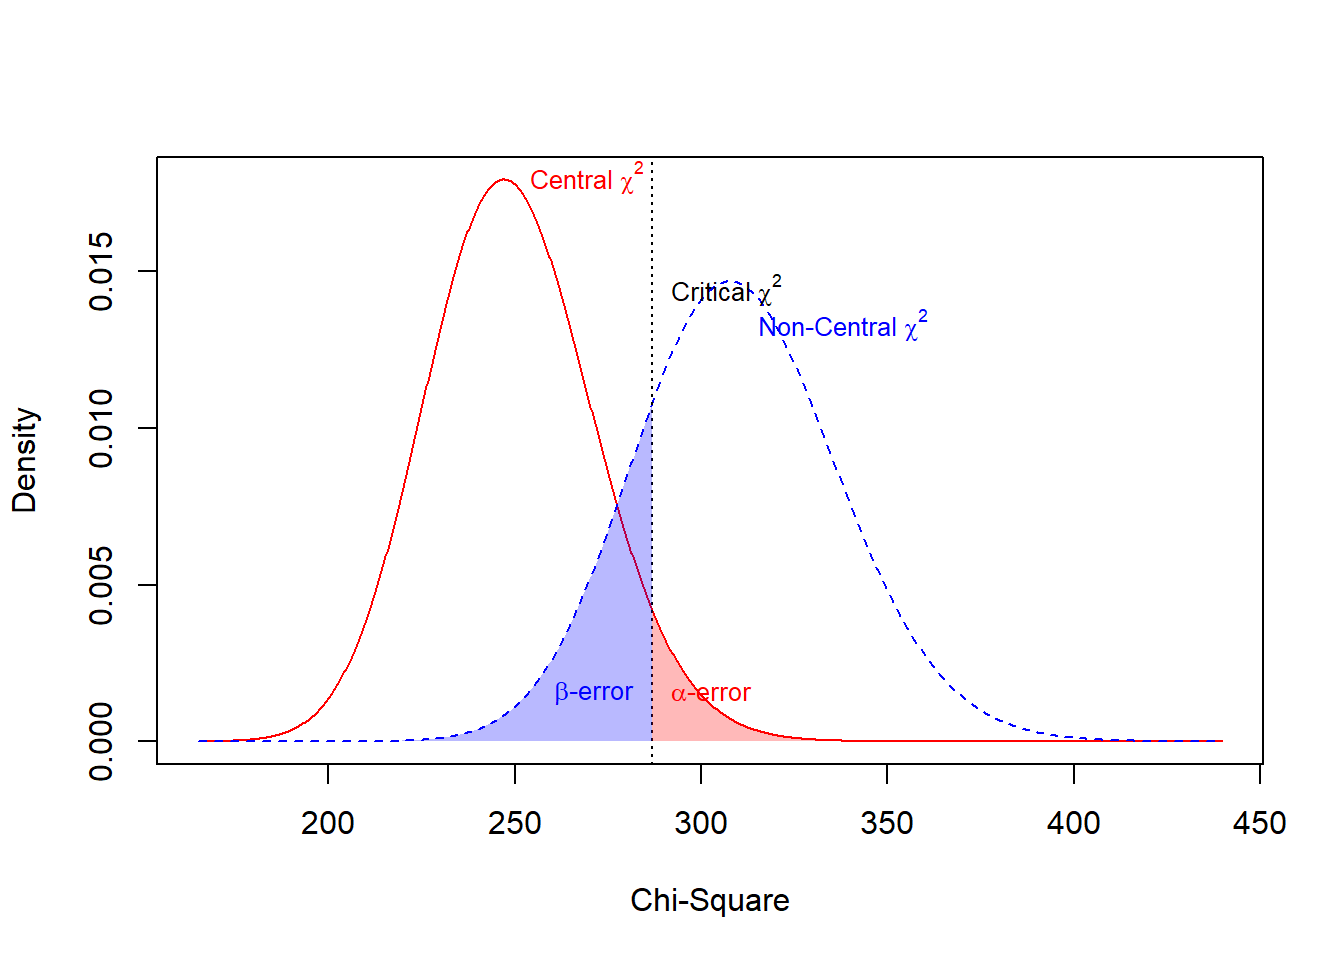

In [ ]:

ap_rmsea <- semPower::semPower.aPriori(
    effect         = 0.05, # RMSEA under H1 (exact-fit model: H0: RMSEA = 0)
    effect.measure = "RMSEA",
    alpha          = ALPHA,
    power          = POWER,
    df             = df_model,
    p              = P # Just for GFI and AGFI
)

summary(ap_rmsea)


### Model-based approach (with lavaan syntax)


 semPower: A priori power analysis
                                   
 F0                        0.285805
 RMSEA                     0.033879
 Mc                        0.866838
                                   
 df                        249     
 Required Num Observations 215     
                                   
 Critical Chi-Square       286.8077
 NCP                       61.16236
 Alpha                     0.050000
 Beta                      0.197630
 Power (1 - Beta)          0.802370
 Implied Alpha/Beta Ratio  0.252998

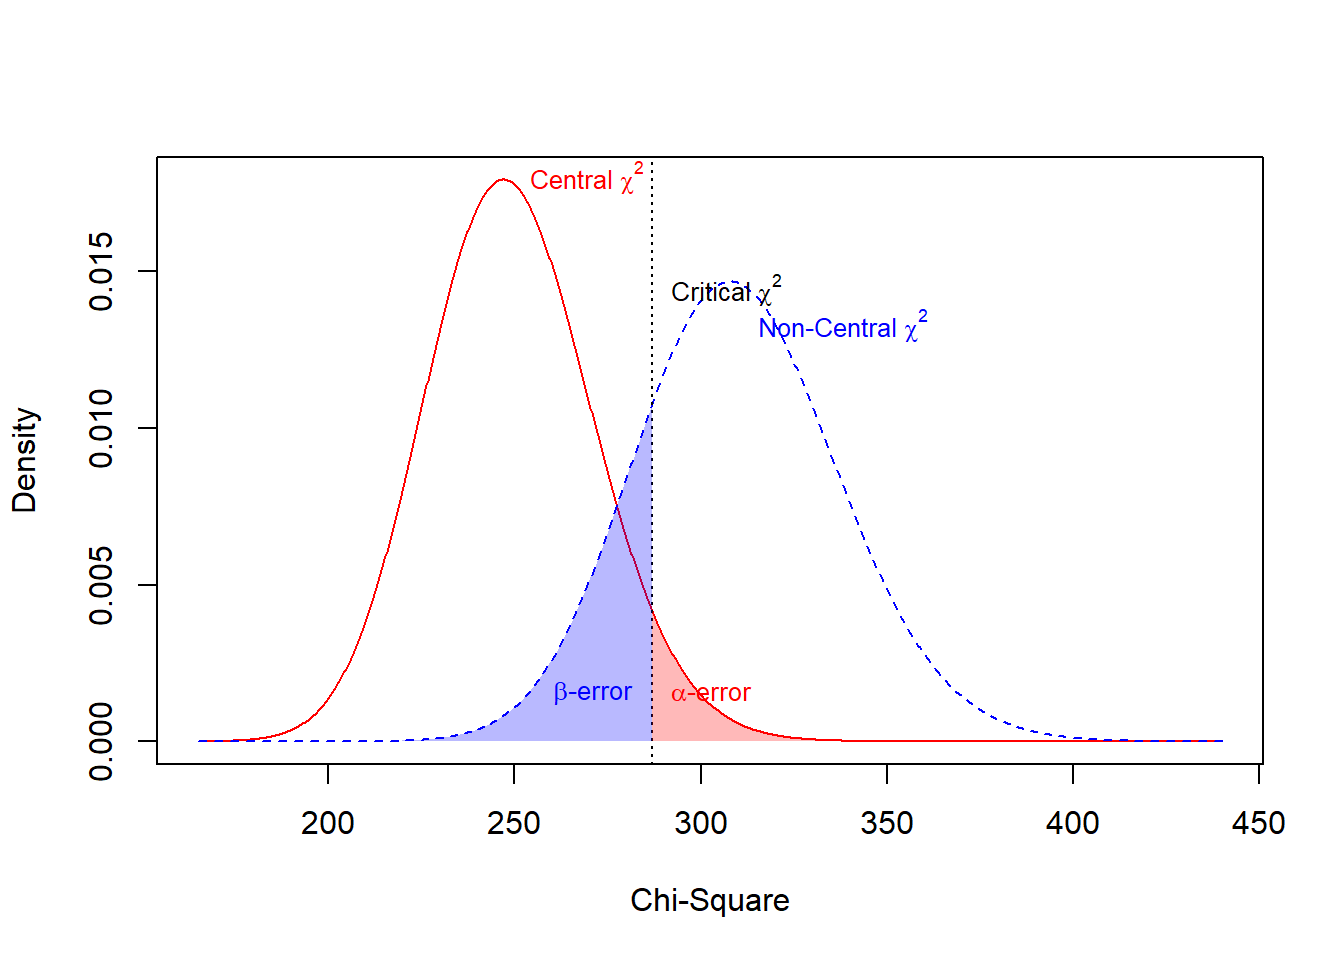

In [ ]:
ap_popmodel <- semPower.powerLav(
  type = 'a-priori',
  alpha = ALPHA,
  power = POWER,
  modelPop = popModel,
  modelH0 = analyzeModel
)

summary(ap_popmodel)


## Power curves

### Model-free approach

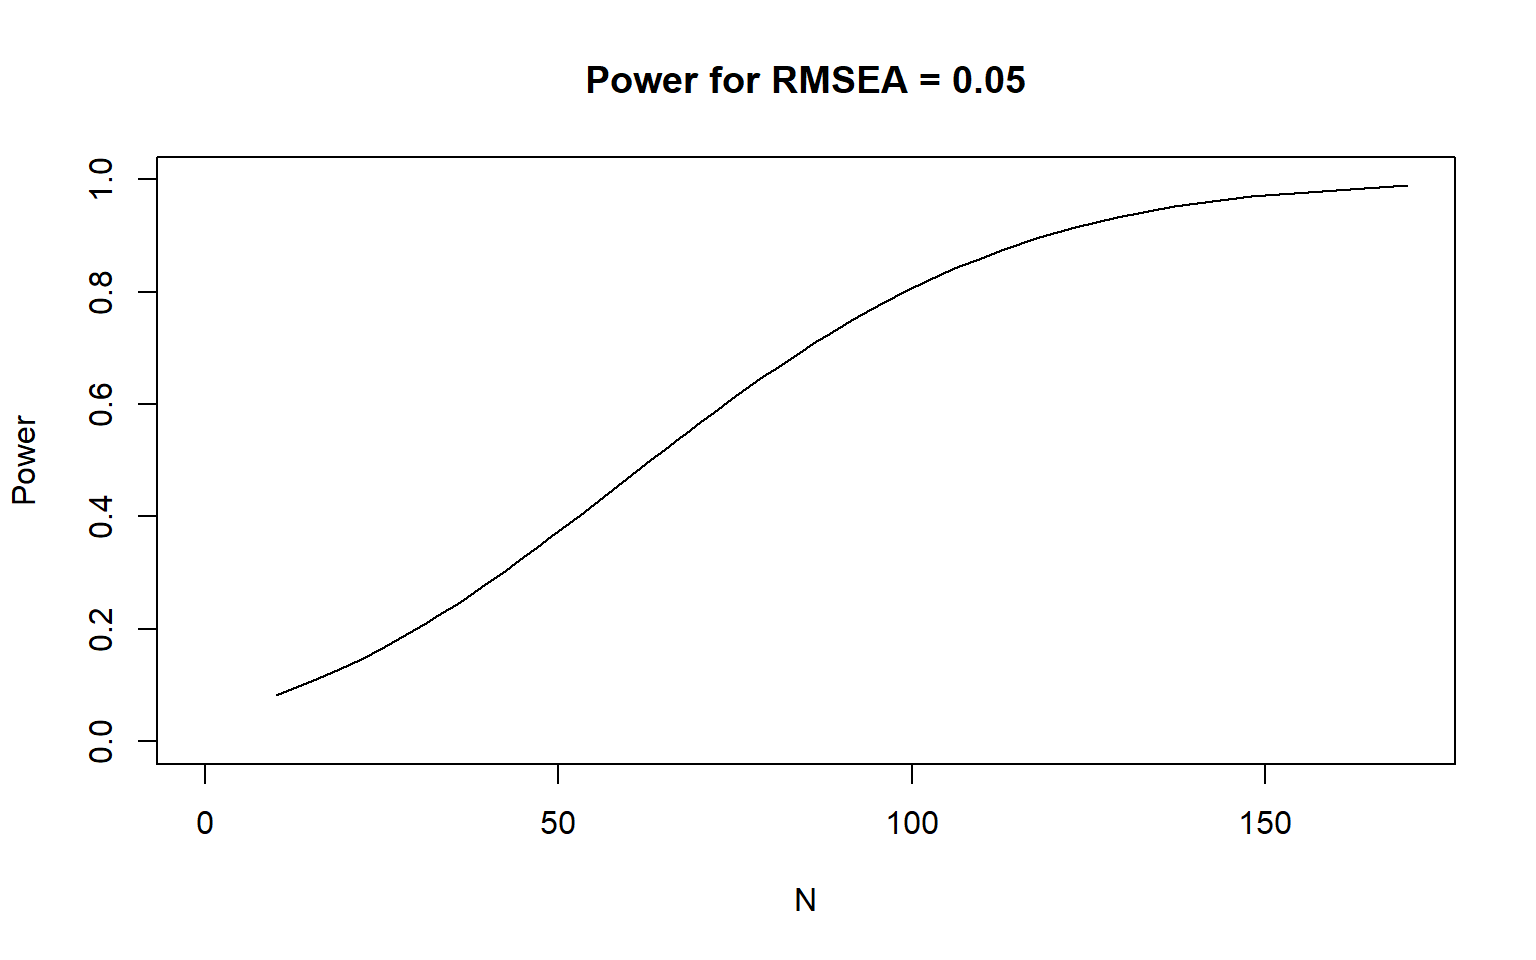

In [ ]:

semPower::semPower.powerPlot.byN(
    effect         = 0.05,
    effect.measure = "RMSEA",
    alpha          = ALPHA,
    df             = df_model,
    power.min      = 0.05,
    power.max      = 0.99
)


### Model-based approach

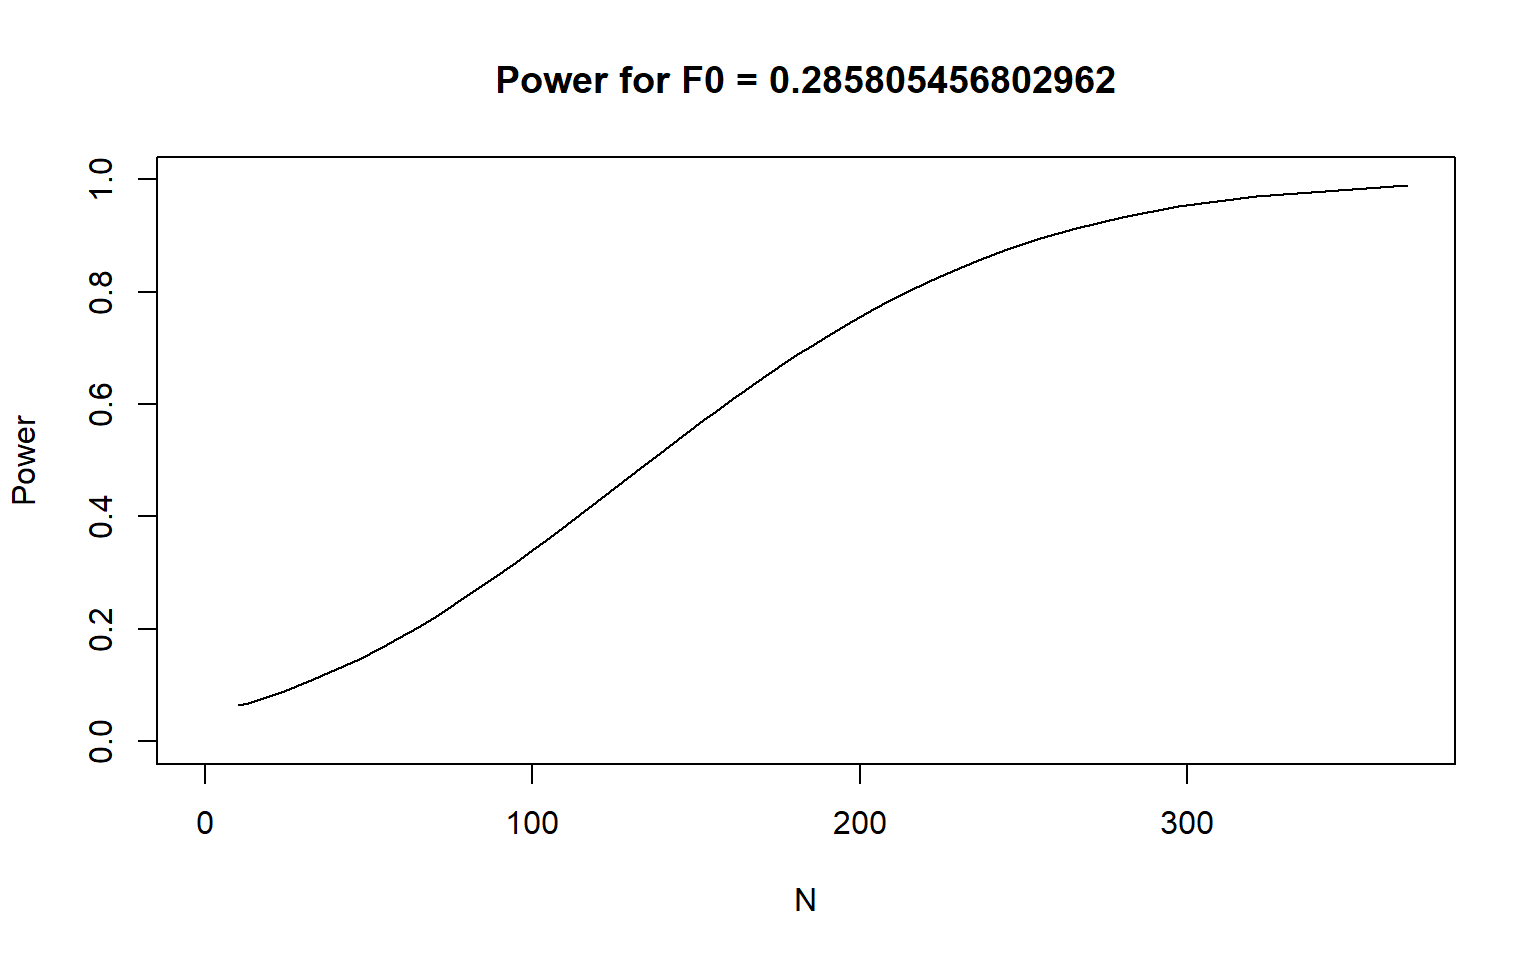

In [ ]:

semPower.powerPlot(ap_popmodel)


## Summary table

In [ ]:

# Helper to ensure length-1 numeric
safe_num <- function(x) if (length(x) == 0 || is.null(x)) NA else as.numeric(x)[1]

analytical_summary <- data.frame(
    Method = c(
        "Model-free a priori (RMSEA ≥ .05)",
        "Model-based a priori (Population Model)"
    ),
    `N Required` = c(
        safe_num(ap_rmsea$requiredN),
        safe_num(ap_popmodel$requiredN)
    ),
    `Power` = c(
        round(safe_num(ap_rmsea$impliedPower), 4),
        round(safe_num(ap_popmodel$impliedPower), 4)
    ),
    `Implied RMSEA` = c(
        round(safe_num(ap_rmsea$rmsea), 4),
        round(safe_num(ap_popmodel$rmsea), 4)
    ),
    `Implied Fmin` = c(
        round(safe_num(ap_rmsea$fmin), 4),
        round(safe_num(ap_popmodel$fmin), 4)
    ),
    df = rep(safe_num(df_model), 2),
    check.names = FALSE
)

knitr::kable(analytical_summary, align = "lccccc")


  -------------------------------------------------------------------------------
  Method                         N Required  Power     Implied    Implied    df
                                                        RMSEA       Fmin    
  ------------------------------ ---------- -------- ----------- ---------- -----
  Model-free a priori (RMSEA ≥       99      0.8008    0.0500      0.6225    249
  .05)                                                                      

  Model-based a priori              215      0.8024    0.0339      0.2858    249
  (Population Model)                                                        
  -------------------------------------------------------------------------------
